<a href="https://colab.research.google.com/github/Nuthana1234/Calibo_assignment_practice/blob/main/Titanic_Simple_Complete_EDA_Classroom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚢 Titanic Dataset — Simple & Complete EDA

## B.Tech Data Science Classroom Version

This notebook covers **all important steps of Exploratory Data Analysis (EDA)** in a simple order.

### EDA Flow

```text
1. Understand the Problem
2. Load the Data
3. Understand the Data
4. Check Data Quality
5. Clean the Data
6. Univariate Analysis
7. Bivariate Analysis
8. Multivariate Analysis
9. Outlier Analysis
10. Feature Engineering
11. Correlation Analysis
12. Final Insights
```

### Golden Rule for Students

> **Before every analysis, ask: "What question am I trying to answer?"**

We are trying to understand:

> **What factors are related to passenger survival on the Titanic?**


# 1. Import Libraries

### Question
**What libraries do we need for EDA?**

- Pandas → Data analysis
- NumPy → Numerical operations
- Matplotlib → Charts
- Seaborn → Easy statistical charts


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 2. Load Titanic Dataset

### Question
**How can we load the Titanic dataset?**


In [ ]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# 3. Understand the Data

## 3.1 How many rows and columns?

### Question
**How big is our dataset?**


In [ ]:
df.shape

(891, 15)

## 3.2 What columns do we have?

### Question
**What information is available about each passenger?**


In [ ]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

### Important columns to remember

| Column | Meaning |
|---|---|
| `survived` | 0 = No, 1 = Yes |
| `pclass` | Passenger class |
| `sex` | Gender |
| `age` | Age |
| `sibsp` | Siblings/spouse |
| `parch` | Parents/children |
| `fare` | Ticket fare |
| `embarked` | Embarkation port |
| `alone` | Travelling alone? |

For our EDA, **`survived` is the main variable we want to understand.**


## 3.3 Look at the first records

### Question
**What does the actual data look like?**


In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3.4 Get basic information

### Question
**What are the data types and how many values are available?**


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


## 3.5 Statistical summary

### Question
**What are the basic statistics of the numerical columns?**


In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 4. Check Data Quality

Before analysis, we should check whether the data has problems.

We mainly check:

1. Missing values
2. Duplicate rows
3. Wrong/strange values
4. Data types


## 4.1 Missing Values

### Question
**Which columns have missing values?**


In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


### Question
**What percentage of the data is missing?**

This is useful because 10 missing values out of 20 rows is very different from 10 missing values out of 10,000 rows.


In [ ]:
(df.isnull().mean() * 100).round(2)

,0
survived,0.00
pclass,0.00
sex,0.00
age,19.87
sibsp,0.00
parch,0.00
fare,0.00
embarked,0.22
class,0.00
who,0.00


## 4.2 Visualize Missing Values

### Question
**Where are the missing values?**


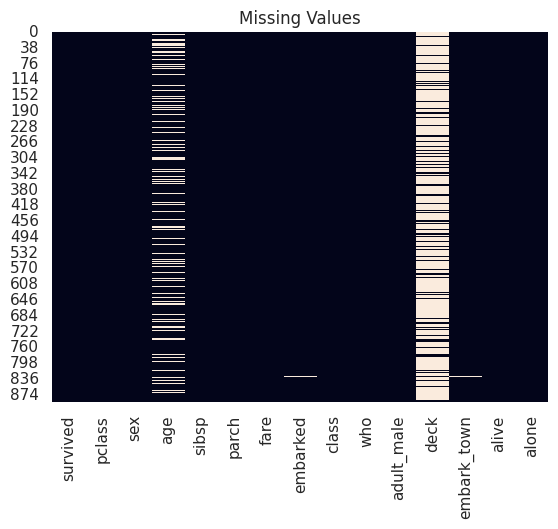

In [ ]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

## 4.3 Duplicate Rows

### Question
**Are there duplicate records?**


In [ ]:
df.duplicated().sum()

np.int64(107)

## 4.4 Data Types

### Question
**Which columns are numerical and which are categorical?**


In [ ]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


# 5. Clean the Data

Now we decide how to handle the problems we found.

### Important principle

> **Do not blindly delete data. Understand the problem first.**


## 5.1 Handle Missing Age

### Question
**What should we do with missing age values?**

For this beginner example, we will use the **median age**.


In [ ]:
df["age"] = df["age"].fillna(df["age"].median())

print("Missing age:", df["age"].isnull().sum())

Missing age: 0


## 5.2 Handle Missing Embarked

### Question
**What should we do with a very small number of missing categorical values?**

For this example, we use the **mode**.


In [ ]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

print("Missing embarked:", df["embarked"].isnull().sum())

Missing embarked: 0


## 5.3 Handle Deck

### Question
**What should we do when a categorical column has many missing values?**

Instead of guessing the deck, we can label missing values as `Unknown`.


In [ ]:
df["deck"] = df["deck"].astype("object").fillna("Unknown")

print("Missing deck:", df["deck"].isnull().sum())

Missing deck: 0


# 6. Univariate Analysis

### Meaning

**Uni = One**

We analyze **one variable at a time**.

Main question:

> **What does this variable look like?**


## 6.1 Survival

### Question
**How many passengers survived?**


In [ ]:
df["survived"].value_counts()

,count
survived,
0,549
1,342


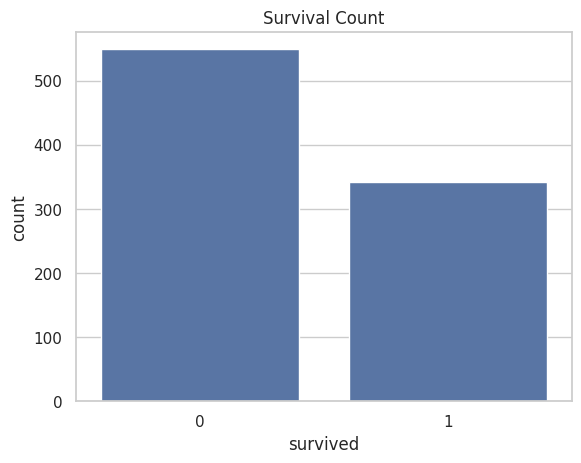

In [ ]:
sns.countplot(data=df, x="survived")
plt.title("Survival Count")
plt.show()

## 6.2 Gender

### Question
**How many male and female passengers were there?**


In [ ]:
df["sex"].value_counts()

,count
sex,
male,577
female,314


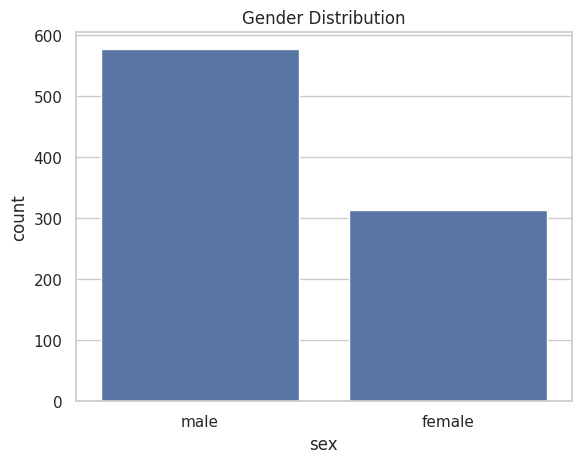

In [ ]:
sns.countplot(data=df, x="sex")
plt.title("Gender Distribution")
plt.show()

## 6.3 Passenger Class

### Question
**How many passengers were in each class?**


In [ ]:
df["class"].value_counts()

,count
class,
Third,491
First,216
Second,184


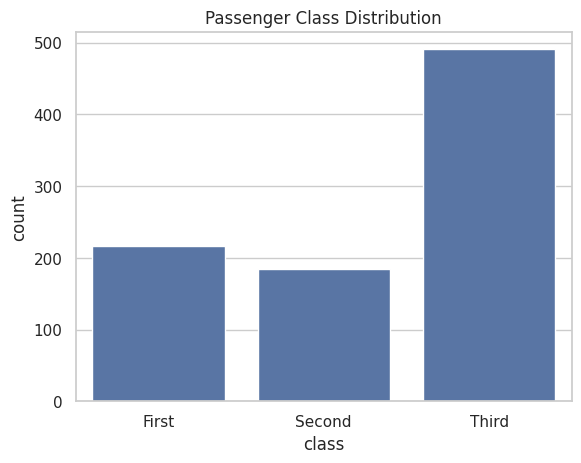

In [ ]:
sns.countplot(data=df, x="class", order=["First", "Second", "Third"])
plt.title("Passenger Class Distribution")
plt.show()

## 6.4 Age

### Question
**What does the age distribution look like?**

A histogram is useful for numerical data.


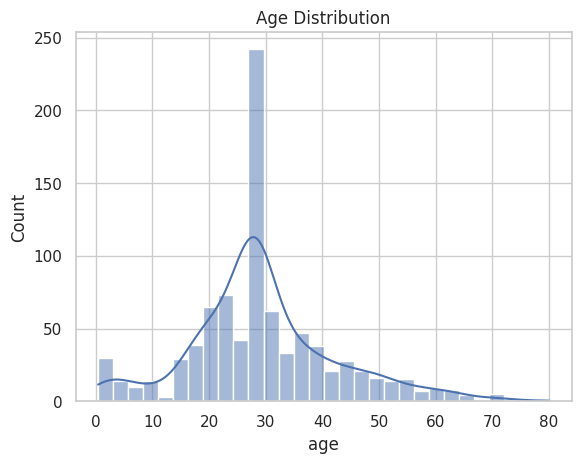

In [ ]:
sns.histplot(data=df, x="age", bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

## 6.5 Fare

### Question
**How are ticket fares distributed?**


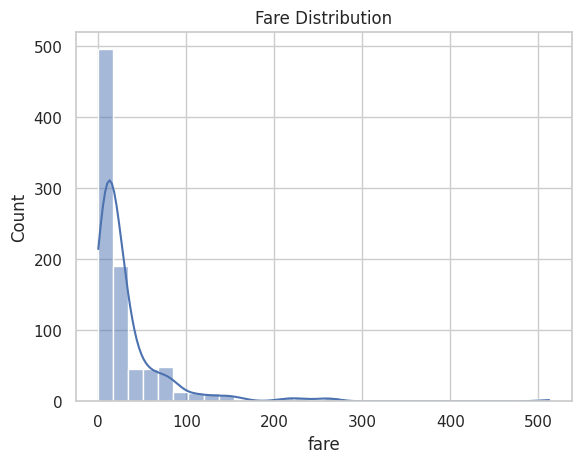

In [ ]:
sns.histplot(data=df, x="fare", bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

# 7. Bivariate Analysis

### Meaning

**Bi = Two**

Now we analyze two variables together.

Our main question is:

> **How is another variable related to survival?**


## 7.1 Gender vs Survival

### Question
**Does survival differ between males and females?**


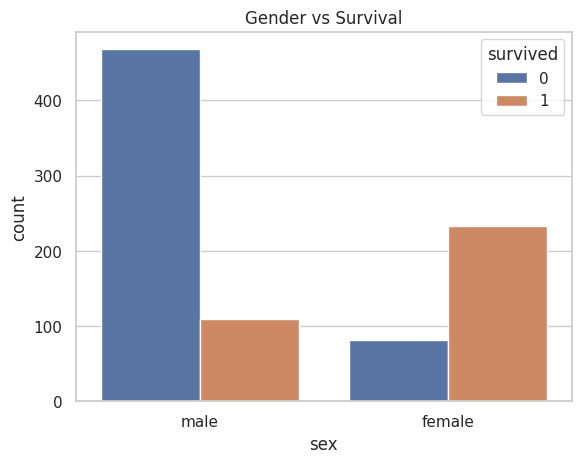

In [ ]:
sns.countplot(data=df, x="sex", hue="survived")
plt.title("Gender vs Survival")
plt.show()

### Calculate survival rate

This is more useful than only looking at counts.

### Question
**What percentage of each gender survived?**


In [ ]:
df.groupby("sex")["survived"].mean()

,survived
sex,
female,0.742038
male,0.188908


## 7.2 Passenger Class vs Survival

### Question
**Does passenger class affect survival?**


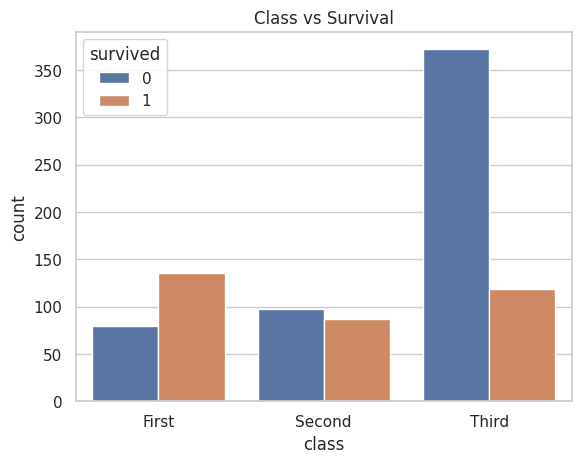

In [ ]:
sns.countplot(
    data=df,
    x="class",
    hue="survived",
    order=["First", "Second", "Third"]
)
plt.title("Class vs Survival")
plt.show()

In [ ]:
df.groupby("class", observed=True)["survived"].mean()

,survived
class,
First,0.629630
Second,0.472826
Third,0.242363


## 7.3 Age vs Survival

### Question
**Is the age distribution different for survivors and non-survivors?**


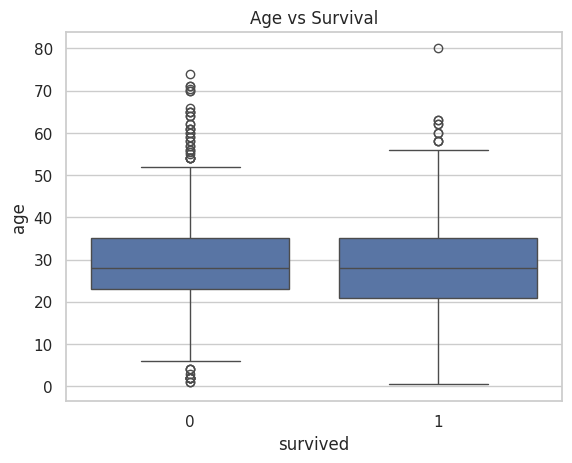

In [ ]:
sns.boxplot(data=df, x="survived", y="age")
plt.title("Age vs Survival")
plt.show()

## 7.4 Fare vs Survival

### Question
**Did passengers paying higher fares have different survival rates?**


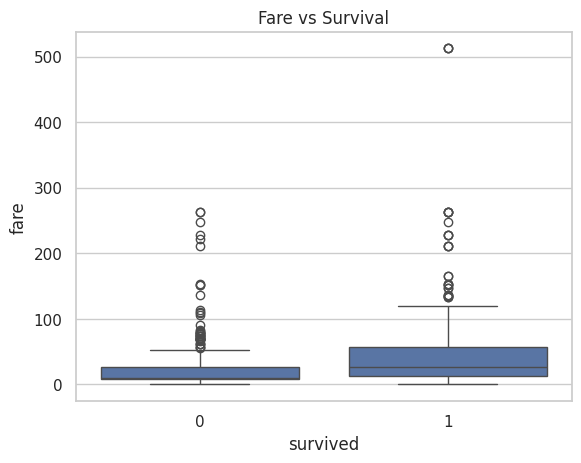

In [ ]:
sns.boxplot(data=df, x="survived", y="fare")
plt.title("Fare vs Survival")
plt.show()

## 7.5 Embarkation vs Survival

### Question
**Does survival differ by the passenger's embarkation port?**


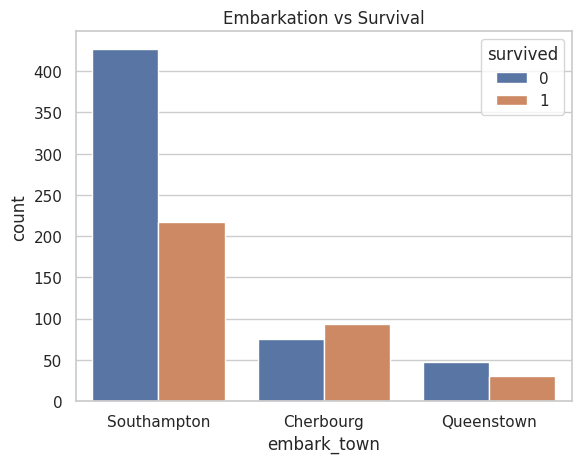

In [ ]:
sns.countplot(data=df, x="embark_town", hue="survived")
plt.title("Embarkation vs Survival")
plt.show()

In [ ]:
df.groupby("embark_town", observed=True)["survived"].mean()

,survived
embark_town,
Cherbourg,0.553571
Queenstown,0.389610
Southampton,0.336957


# 8. Family Analysis

Family information is useful because people did not always travel alone.

## 8.1 Create Family Size

### Question
**Can we create a new feature showing the total family size?**

Formula:

```text
Family Size = SibSp + Parch + 1
```


In [ ]:
df["family_size"] = df["sibsp"] + df["parch"] + 1

df[["sibsp", "parch", "family_size"]].head()

,sibsp,parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


## 8.2 Family Size vs Survival

### Question
**Does family size appear related to survival?**


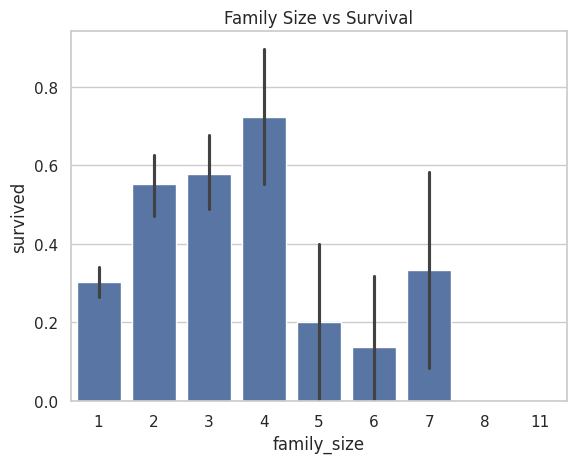

In [ ]:
sns.barplot(data=df, x="family_size", y="survived")
plt.title("Family Size vs Survival")
plt.show()

## 8.3 Travelling Alone vs Survival

### Question
**Did passengers travelling alone have a different survival rate?**


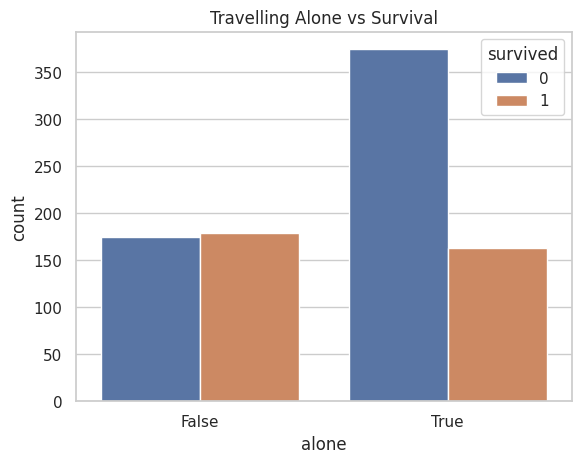

In [ ]:
sns.countplot(data=df, x="alone", hue="survived")
plt.title("Travelling Alone vs Survival")
plt.show()

In [ ]:
df.groupby("alone")["survived"].mean()

,survived
alone,
False,0.505650
True,0.303538


# 9. Multivariate Analysis

### Meaning

**Multi = More than two variables**

Now we ask questions involving three or more variables.


## 9.1 Gender + Class + Survival

### Question
**Does survival depend on both gender and passenger class?**


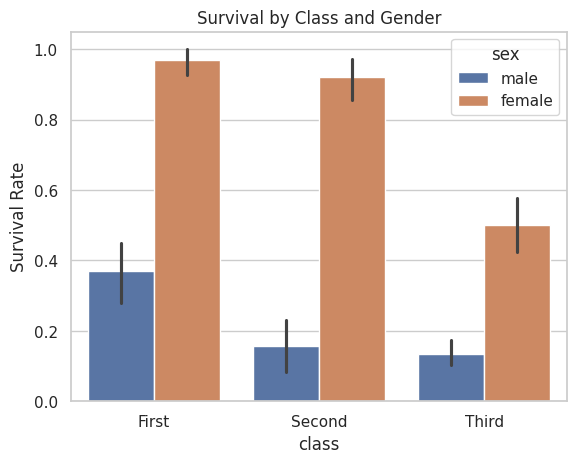

In [ ]:
sns.barplot(
    data=df,
    x="class",
    y="survived",
    hue="sex",
    order=["First", "Second", "Third"]
)
plt.title("Survival by Class and Gender")
plt.ylabel("Survival Rate")
plt.show()

## 9.2 Age + Class + Survival

### Question
**How does age differ across passenger classes and survival status?**


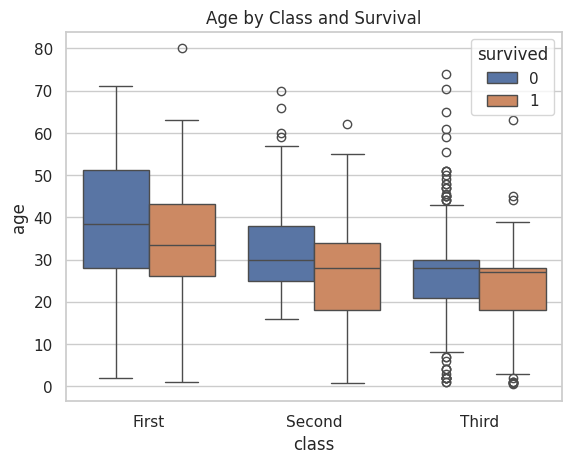

In [ ]:
sns.boxplot(
    data=df,
    x="class",
    y="age",
    hue="survived",
    order=["First", "Second", "Third"]
)
plt.title("Age by Class and Survival")
plt.show()

## 9.3 Age + Fare + Survival

### Question
**Is there a relationship between age and fare, and does survival differ?**


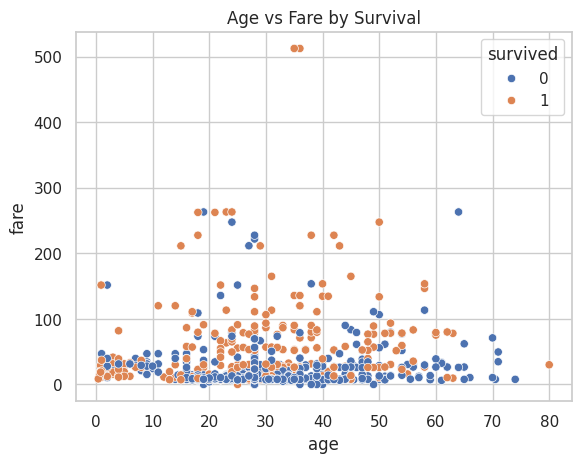

In [ ]:
sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived"
)
plt.title("Age vs Fare by Survival")
plt.show()

# 10. Outlier Analysis

### Question
**Are there unusual values in our numerical columns?**

We can start with a box plot.


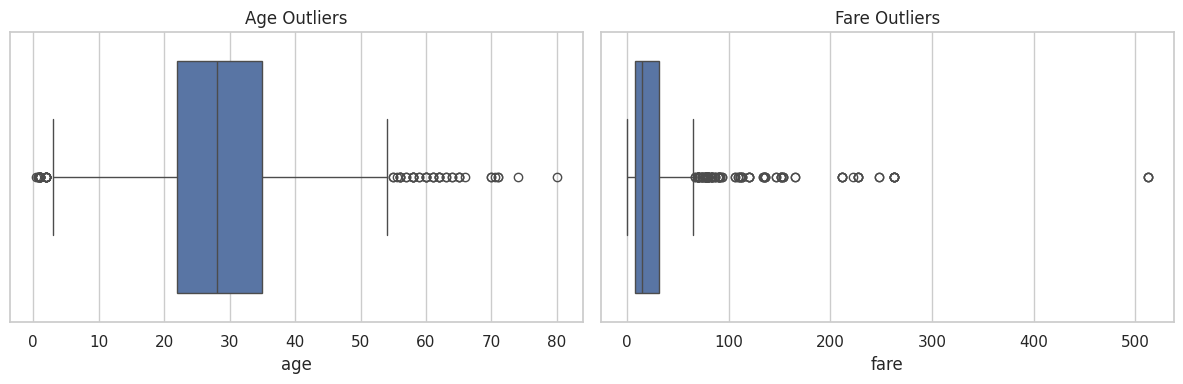

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x="age", ax=axes[0])
axes[0].set_title("Age Outliers")

sns.boxplot(data=df, x="fare", ax=axes[1])
axes[1].set_title("Fare Outliers")

plt.tight_layout()
plt.show()

## IQR Method

### Question
**How can we mathematically identify potential outliers?**

Formula:

```text
IQR = Q3 - Q1

Lower Limit = Q1 - 1.5 × IQR
Upper Limit = Q3 + 1.5 × IQR
```


In [ ]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["fare"] < lower) |
    (df["fare"] > upper)
]

print("Number of fare outliers:", len(outliers))
outliers.head()

Number of fare outliers: 116


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,C,Southampton,no,False,6
31,1,1,female,28.0,1,0,146.5208,C,First,woman,False,B,Cherbourg,yes,False,2
34,0,1,male,28.0,1,0,82.1708,C,First,man,True,Unknown,Cherbourg,no,False,2
52,1,1,female,49.0,1,0,76.7292,C,First,woman,False,D,Cherbourg,yes,False,2


### Important

> **Outlier does not automatically mean wrong data.**

A high Titanic fare could be a genuine first-class or group ticket.

Always investigate before deleting.


# 11. Correlation Analysis

### Question
**Which numerical variables are related to each other?**

Correlation gives us the strength and direction of a linear relationship.


In [ ]:
numeric_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation = df[numeric_columns].corr()

correlation

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
sibsp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


## Correlation Heatmap

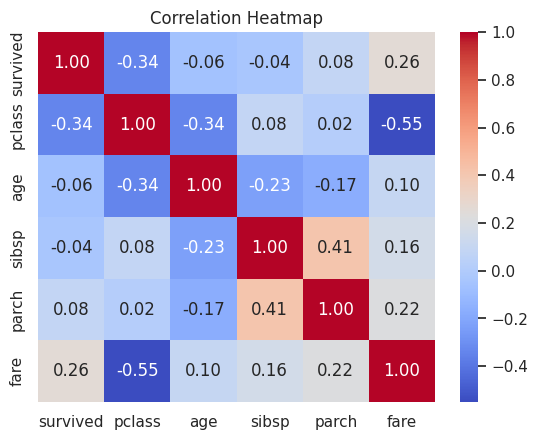

In [ ]:
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

### Remember

```text
+1  → Strong positive relationship
 0  → Little/no linear relationship
-1  → Strong negative relationship
```

> **Correlation does not mean causation.**


# 12. Simple Group Analysis

### Question
**What is the survival rate for each gender and class combination?**

This is a very useful way to summarize our findings.


In [ ]:
df.groupby(
    ["sex", "class"],
    observed=True
)["survived"].mean()

sex     class 
female  First     0.968085
        Second    0.921053
        Third     0.500000
male    First     0.368852
        Second    0.157407
        Third     0.135447
Name: survived, dtype: float64

# 13. Pivot Table

### Question
**Can we see the same survival rates in a simple table?**


In [ ]:
pd.pivot_table(
    df,
    values="survived",
    index="sex",
    columns="class",
    aggfunc="mean"
)

/tmp/ipykernel_1220/3477933537.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(


class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


# 14. Feature Engineering

### Question
**Can we create useful new columns from existing columns?**

We already created `family_size`.

Now create a simple child/adult feature.


In [ ]:
df["is_child"] = df["age"] < 18

df[["age", "is_child"]].head()

,age,is_child
0,22.0,False
1,38.0,False
2,26.0,False
3,35.0,False
4,35.0,False


### Question
**Did children have a different survival rate from adults?**


In [ ]:
df.groupby("is_child")["survived"].mean()

,survived
is_child,
False,0.361183
True,0.539823


# 15. Final Data Quality Check

### Question
**After cleaning, do important missing values still remain?**


In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


# 16. Final EDA Summary

At this point we have covered the complete EDA process:

### ✅ Data Understanding
- Shape
- Columns
- Head
- Info
- Describe
- Datatypes

### ✅ Data Quality
- Missing values
- Missing percentages
- Missing-value visualization
- Duplicates
- Cleaning

### ✅ Univariate Analysis
- Survival
- Gender
- Class
- Age
- Fare

### ✅ Bivariate Analysis
- Gender vs survival
- Class vs survival
- Age vs survival
- Fare vs survival
- Embarkation vs survival
- Family size vs survival
- Alone vs survival

### ✅ Multivariate Analysis
- Gender + class + survival
- Age + class + survival
- Age + fare + survival

### ✅ Outlier Analysis
- Box plot
- IQR

### ✅ Feature Engineering
- Family size
- Child/adult

### ✅ Relationship Analysis
- Correlation
- GroupBy
- Pivot table

### ✅ Final Insights
- Convert analysis into meaningful conclusions


# 🏆 Final Questions for Students

Now close the notebook and answer these questions using your analysis.

### Basic
1. How many passengers are there?
2. How many columns are there?
3. Which columns have missing values?
4. Which column has the most missing values?

### Univariate
5. How many passengers survived?
6. Which gender had more passengers?
7. Which passenger class had more passengers?
8. What does the age distribution look like?
9. Is fare normally distributed?

### Bivariate
10. Does gender appear related to survival?
11. Does passenger class appear related to survival?
12. Does age appear related to survival?
13. Does fare appear related to survival?
14. Does travelling alone appear related to survival?

### Multivariate
15. How does gender + class affect survival?
16. How does age + class affect survival?

### Data Quality
17. Which columns contain missing values?
18. How did we handle missing age?
19. How did we handle missing embarked?
20. What did we do with deck?

### Final Insight
21. What are your **top 5 findings** from the Titanic dataset?

---

## ⭐ Remember

> **EDA is not "draw some graphs."**

The real process is:

```text
ASK A QUESTION
      ↓
GET THE DATA
      ↓
UNDERSTAND THE DATA
      ↓
CHECK & CLEAN
      ↓
ANALYZE
      ↓
VISUALIZE
      ↓
FIND PATTERNS
      ↓
GET INSIGHTS
      ↓
MAKE A DECISION
```


# 📌 EDA Cheat Sheet

| Step | Question | Common Code/Chart |
|---|---|---|
| Load | Did data load? | `sns.load_dataset()` |
| Shape | How big is it? | `df.shape` |
| Columns | What features exist? | `df.columns` |
| Preview | What does it look like? | `df.head()` |
| Info | What are the types? | `df.info()` |
| Statistics | What are the basic statistics? | `df.describe()` |
| Missing | What is missing? | `df.isnull().sum()` |
| Duplicate | Are rows repeated? | `df.duplicated()` |
| Univariate | What does one variable look like? | Histogram / Countplot |
| Bivariate | How are two variables related? | Bar / Box / Scatter |
| Multivariate | How do multiple variables interact? | Grouped plots |
| Outliers | Which values are unusual? | Boxplot / IQR |
| Correlation | Which numerical variables are related? | Correlation / Heatmap |
| Feature Engineering | Can we create useful features? | New columns |
| Insights | What did we learn? | Numbers + Charts |

### 🎯 Golden Rule for Every EDA

> **Question → Code → Visualization → Observation → Insight**
